## 1. Introducción
Este notebook implementa un sistema de detección de manchas solares utilizando el modelo de detección de objetos YOLOv8.
El objetivo es identificar y localizar manchas solares en imágenes solares.
Utilizaremos un modelo YOLOv8 pre-entrenado y lo ajustaremos (fine-tuning) con un dataset de imágenes de manchas solares.
**Nota:** Este notebook utiliza un dataset externo para el entrenamiento debido a problemas con la generación automática de anotaciones a partir de los datos SRS.


### Importar Biblioteca

In [1]:
import os
import glob
import time
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, display
from PIL import Image as PILImage, ImageDraw
#from PIL import Image
import yaml

%matplotlib inline


In [2]:
new_dataset_config = r"C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP.yaml"  # Ruta al archivo data.yaml
trained_model_path = "OGAUC_model/OGAUC_simple_nano/weights/best.pt"
model = YOLO(trained_model_path)


## Visualizar Predicciones en Imágenes de Prueba

In [ ]:
import os

def convert_labels_to_single_class(directory):
    """
    Recorre todos los archivos .txt en un directorio y cambia el ID de clase a 0.
    """
    label_dir = os.path.join(directory, 'labels')
    if not os.path.isdir(label_dir):
        print(f"Directorio de etiquetas no encontrado en: {label_dir}")
        return

    print(f"Procesando directorio: {label_dir}")
    file_count = 0
    for filename in os.listdir(label_dir):
        if filename.endswith(".txt"):
            file_path = os.path.join(label_dir, filename)
            
            with open(file_path, 'r') as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    # Cambia el primer elemento (class_id) a '0'
                    parts[0] = '0'
                    new_lines.append(" ".join(parts) + "\n")

            with open(file_path, 'w') as f:
                f.writelines(new_lines)
            
            file_count += 1
    print(f"Procesados {file_count} archivos en {label_dir}.")


# --- CONFIGURACIÓN ---
# Ajusta esta ruta a la carpeta que contiene los directorios train/valid/test
# En tu caso, parece ser la carpeta 'dataset/NISP'
base_path = r'c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP'

dirs_to_process = [
    r"C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\train",
    r"C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\valid",
    r"C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\test",
]

for d in dirs_to_process:
    convert_labels_to_single_class(d)

print("\n¡Conversión completada!")

Procesando directorio: C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\train\labels
Procesados 438 archivos en C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\train\labels.
Procesando directorio: C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\valid\labels
Procesados 42 archivos en C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\valid\labels.
Procesando directorio: C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\test\labels
Procesados 21 archivos en C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\test\labels.

¡Conversión completada!


In [ ]:
metrics = model.val(data=new_dataset_config)
print("--- Métricas en Validation Set ---")
print(f"Precisión: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

# Obtener la matriz de confusión
conf_matrix = metrics.confusion_matrix.matrix

# Para una clase: TP es la diagonal, FN es la última columna, FP es la última fila
tp = conf_matrix[0, 0]
fn = conf_matrix[0, 1]
fp = conf_matrix[1, 0]

print("\nMatriz de Confusión (Validation Set):")
print(f"True Positives (TP): {int(tp)}")
print(f"False Negatives (FN): {int(fn)}")
print(f"False Positives (FP): {int(fp)}")

Ultralytics 8.3.158  Python-3.13.5 torch-2.7.1+cpu CPU (AMD Ryzen 7 8700G w/ Radeon 780M Graphics)
val: Fast image access  (ping: 0.00.0 ms, read: 485.6129.4 MB/s, size: 28.1 KB)


val: Scanning C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\valid\labels... 42 images, 0 backgrounds, 0 corrupt: 100%|██████████| 42/42 [00:00<00:00, 873.64it/s]

val: New cache created: C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\valid\labels.cache



c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.93it/s]


                   all         42        273       0.26      0.297      0.183     0.0428
Speed: 0.7ms preprocess, 32.2ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\runs\detect\val13
--- Métricas en Validation Set ---
Precisión: 0.2601
Recall: 0.2967
mAP50: 0.1825
mAP50-95: 0.0428

Matriz de Confusión (Validation Set):
True Positives (TP): 104
False Negatives (FN): 286
False Positives (FP): 169


In [ ]:
metrics_test = model.val(data=new_dataset_config, split='test')
print("\n--- Métricas en Test Set ---")
print(f"Precisión: {metrics_test.box.p[0]:.4f}")
print(f"Recall: {metrics_test.box.r[0]:.4f}")
print(f"mAP50: {metrics_test.box.map50:.4f}")
print(f"mAP50-95: {metrics_test.box.map:.4f}")

# Obtener la matriz de confusión del test set
conf_matrix_test = metrics_test.confusion_matrix.matrix

# Para una clase: TP es la diagonal, FN es la última columna, FP es la última fila
tp_test = conf_matrix_test[0, 0]
fn_test = conf_matrix_test[0, 1]
fp_test = conf_matrix_test[1, 0]

print("\nMatriz de Confusión (Test Set):")
print(f"True Positives (TP): {int(tp_test)}")
print(f"False Negatives (FN): {int(fn_test)}")
print(f"False Positives (FP): {int(fp_test)}")

Ultralytics 8.3.158  Python-3.13.5 torch-2.7.1+cpu CPU (AMD Ryzen 7 8700G w/ Radeon 780M Graphics)
val: Fast image access  (ping: 0.00.0 ms, read: 701.9160.8 MB/s, size: 57.8 KB)


val: Scanning C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\ROB\test\labels.cache... 81 images, 0 backgrounds, 0 corrupt: 100%|██████████| 81/81 [00:00<?, ?it/s]
c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.11it/s]


                   all         81        336      0.111      0.131     0.0641      0.015
Speed: 0.4ms preprocess, 26.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\runs\detect\val10

--- Métricas en Test Set ---
Precisión: 0.1111
Recall: 0.1310
mAP50: 0.0641
mAP50-95: 0.0150

Matriz de Confusión (Test Set):
True Positives (TP): 51
False Negatives (FN): 274
False Positives (FP): 285


In [11]:
# Obtener una lista de imágenes de prueba
test_images = glob.glob("dataset/NISP/valid/images/*.jpg")

# Seleccionar una imagen aleatoria
random_img_path = random.choice(test_images)
print(f"Imagen seleccionada: {random_img_path}")

Imagen seleccionada: dataset/NISP/valid/images\bbiqa240805t0104_dim-860_jpg.rf.c8de22039a5b05df95d099e330e15d35.jpg


In [12]:
# Cargar la imagen
img = cv2.imread(random_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Obtener la ruta al archivo de etiquetas correspondiente
label_path = random_img_path.replace("images", "labels").replace(".jpg", ".txt")

# Cargar etiquetas (ground truth)
labels = []

with open(label_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])
        # Convertir coordenadas normalizadas a píxeles
        img_height, img_width = img.shape[:2]
        x1 = int((x_center - width / 2) * img_width)
        y1 = int((y_center - height / 2) * img_height)
        x2 = int((x_center + width / 2) * img_width)
        y2 = int((y_center + height / 2) * img_height)
        labels.append((class_id, x1, y1, x2, y2))

labels

[(0, 39, 344, 81, 393),
 (0, 128, 367, 186, 395),
 (0, 201, 364, 232, 398),
 (0, 241, 367, 273, 397),
 (0, 299, 434, 332, 476),
 (0, 341, 441, 382, 469),
 (0, 452, 215, 500, 244),
 (0, 258, 252, 307, 278)]

In [13]:
# Crear una copia para dibujar las etiquetas ground truth
img_gt = img.copy()
for idx, label in enumerate(labels):
    class_id, x1, y1, x2, y2 = label
    cv2.rectangle(img_gt, (x1, y1), (x2, y2), (0, 255, 0), 2)
    text_y = max(y1 - 10, 10)
    cv2.putText(
        img_gt,
        f"{idx}",
        (x1, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

# Realizar predicción con el modelo entrenado (sin filtrar por confianza)
pred_results = model.predict(random_img_path)

# Dibujar las predicciones con su confianza
img_pred = img.copy()
for idx, box in enumerate(pred_results[0].boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    conf = float(box.conf[0])
    #class_id = int(box.cls[0])
    cv2.rectangle(img_pred, (x1, y1), (x2, y2), (255, 0, 0), 2)
    # Asegura que el texto esté dentro de la imagen
    text_y = max(y1 - 10, 10)
    cv2.putText(
        img_pred,
        f"{idx}",
        (x1, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2,
        cv2.LINE_AA,
    )


image 1/1 c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\NISP\valid\images\bbiqa240805t0104_dim-860_jpg.rf.c8de22039a5b05df95d099e330e15d35.jpg: 640x640 14 sunspots, 31.5ms
Speed: 1.2ms preprocess, 31.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


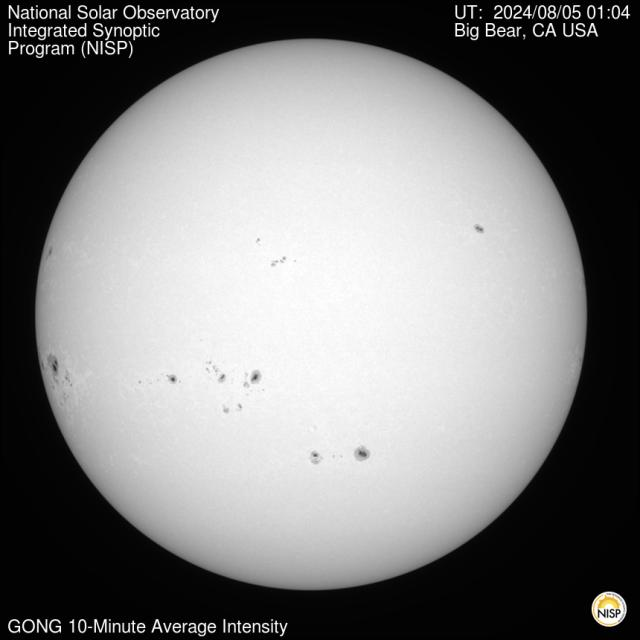

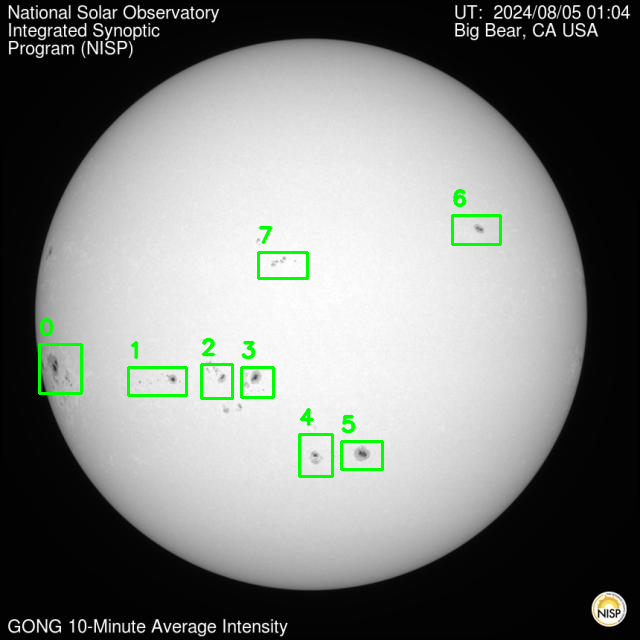

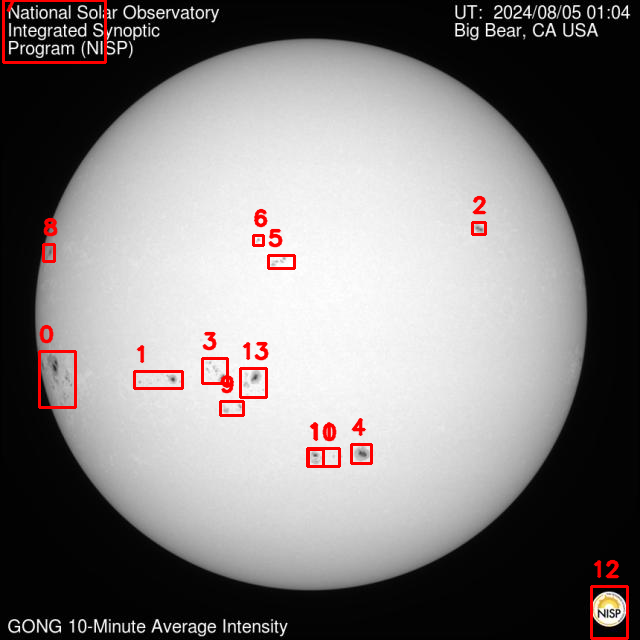

In [14]:
img_pil = PILImage.fromarray(img)
display(img_pil)
img_gt_pil = PILImage.fromarray(img_gt)
display(img_gt_pil)
img_pre_pil = PILImage.fromarray(img_pred)
display(img_pre_pil)

In [18]:
print("Labels:", len(labels))
print("Predictions:", len(pred_results[0].boxes))
for idx, box in enumerate(pred_results[0].boxes):
    conf = float(box.conf[0])
    print(f"Predicción {idx}: {box.xyxy[0].tolist()} con confianza {conf:.2f}")
    

Labels: 7
Predictions: 9
Predicción 0: [136.33251953125, 175.1550750732422, 165.7962646484375, 201.38169860839844] con confianza 0.83
Predicción 1: [185.7332305908203, 225.03448486328125, 195.26881408691406, 234.92535400390625] con confianza 0.80
Predicción 2: [173.53836059570312, 279.97857666015625, 202.22305297851562, 295.89593505859375] con confianza 0.79
Predicción 3: [550.696044921875, 344.8197937011719, 559.9580078125, 355.0585632324219] con confianza 0.75
Predicción 4: [556.71875, 368.77679443359375, 576.90234375, 386.04339599609375] con confianza 0.67
Predicción 5: [331.42633056640625, 344.1898498535156, 348.92425537109375, 356.3890686035156] con confianza 0.54
Predicción 6: [2.0590438842773438, 0.0, 106.61331939697266, 62.4765625] con confianza 0.48
Predicción 7: [591.0791015625, 586.8858642578125, 627.828125, 638.9105224609375] con confianza 0.42
Predicción 8: [325.14239501953125, 343.9776916503906, 349.06439208984375, 357.7978820800781] con confianza 0.29
